# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.

(976, 12)
Unnamed: 0           int64
Make                   str
Make_Year            int64
Color                  str
Body_Type              str
Mileage_Run          int64
No_of_Owners           str
Seating_Capacity     int64
Fuel_Type              str
Transmission           str
Transmission_Type      str
Price                int64
dtype: object
       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000          4.000000  1.880000e+05
25%    244.750000  2015.000000  22676.750000          5.000000  4.757500e+05
50%    488.500000  2017.000000  37570.500000          5.000000  6.665000e+05
75%    732.250000  2019.000000  57421.250000          5.000000  8.830000e+05
max    976.000000  2022.000000  9949

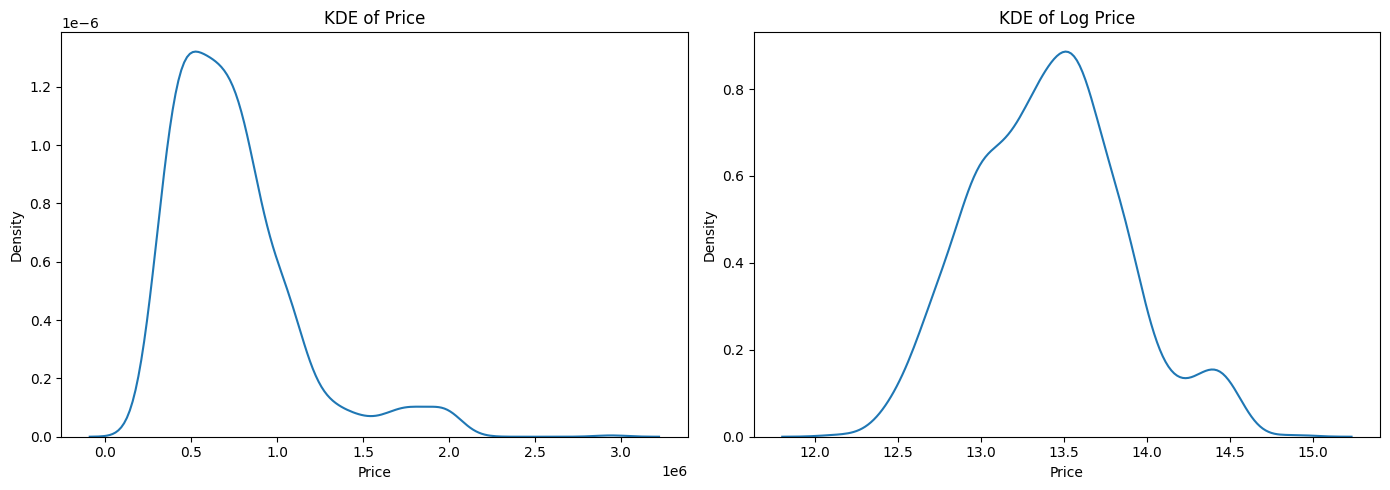


--- Make ---
Make
MG Motors        1.869457e+06
Kia              1.614750e+06
Jeep             1.499500e+06
Skoda            1.136000e+06
Mahindra         1.100167e+06
Tata             1.055217e+06
Nissan           8.842500e+05
Toyota           8.003400e+05
Honda            7.989726e+05
Ford             7.211731e+05
Hyundai          6.918918e+05
Renault          6.625735e+05
Volkswagen       6.058276e+05
Maruti Suzuki    5.887850e+05
Chevrolet        4.535000e+05
Datsun           2.896667e+05
Name: Price, dtype: float64

--- Color ---
Color
black     1.023514e+06
maroon    8.783333e+05
white     8.197750e+05
brown     8.026714e+05
red       7.641176e+05
orange    7.506316e+05
blue      7.207500e+05
yellow    6.948333e+05
silver    6.759470e+05
grey      6.446829e+05
golden    6.213333e+05
bronze    5.585000e+05
beige     5.500000e+05
purple    3.273333e+05
green     3.125000e+05
Name: Price, dtype: float64

--- Body_Type ---
Body_Type
suv          1.176495e+06
sedan        8.097841e+0

C:\Users\elyse\AppData\Local\Temp\ipykernel_57620\3980998105.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


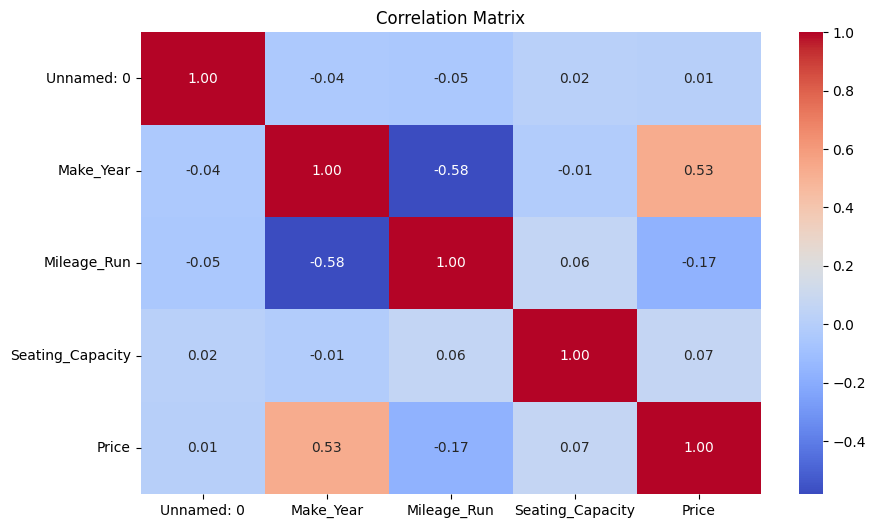

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/cars_hw.csv')  

# 1. Basic overview
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())

# 2. Distribution of price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(df['Price'], ax=axes[0]).set_title('KDE of Price')
sns.kdeplot(np.log(df['Price']), ax=axes[1]).set_title('KDE of Log Price')
plt.tight_layout()
plt.show()

# 3. Price by key categorical variables
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Price'].mean().sort_values(ascending=False))

# 4. Correlations among numeric variables
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.

In [15]:
# Drop unnamed index column
df = df.drop(columns='Unnamed: 0')

# Log transform price (right skewed) and mileage
df['log_price'] = np.log(df['Price'])
df['log_mileage'] = np.log(df['Mileage_Run'])

# Age of car is more intuitive than Make_Year
df['Age'] = 2026 - df['Make_Year']

# One-hot encode categoricals
cat_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.dtypes)

(976, 49)
Make_Year                     int64
Mileage_Run                   int64
Seating_Capacity              int64
Price                         int64
log_price                   float64
log_mileage                 float64
Age                           int64
Make_Datsun                    bool
Make_Ford                      bool
Make_Honda                     bool
Make_Hyundai                   bool
Make_Jeep                      bool
Make_Kia                       bool
Make_MG Motors                 bool
Make_Mahindra                  bool
Make_Maruti Suzuki             bool
Make_Nissan                    bool
Make_Renault                   bool
Make_Skoda                     bool
Make_Tata                      bool
Make_Toyota                    bool
Make_Volkswagen                bool
Color_black                    bool
Color_blue                     bool
Color_bronze                   bool
Color_brown                    bool
Color_golden                   bool
Color_green       

3. Implement an ~80/~20 train-test split. Put the test data aside.

In [16]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Price', 'log_price', 'Make_Year', 'Mileage_Run'])
y = df_encoded['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 780 rows
Test:  196 rows


4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    print(f"\n{name}")
    print(f"  Train R²: {r2_score(y_tr, tr_pred):.4f} | Train RMSE: {root_mean_squared_error(y_tr, tr_pred):.4f}")
    print(f"  Test  R²: {r2_score(y_te, te_pred):.4f} | Test  RMSE: {root_mean_squared_error(y_te, te_pred):.4f}")
    return model

num_cols  = ['Age', 'log_mileage', 'Seating_Capacity']
cat_cols  = [c for c in X_train.columns if c not in num_cols]

# Model 1: numeric only
m1 = evaluate("Model 1: Numeric only",
    LinearRegression(), X_train[num_cols], X_test[num_cols], y_train, y_test)

# Model 2: categorical only
m2 = evaluate("Model 2: Categorical only",
    LinearRegression(), X_train[cat_cols], X_test[cat_cols], y_train, y_test)

# Model 3: all features
m3 = evaluate("Model 3: Combined",
    LinearRegression(), X_train, X_test, y_train, y_test)


Model 1: Numeric only
  Train R²: 0.4248 | Train RMSE: 0.3435
  Test  R²: 0.4000 | Test  RMSE: 0.3383

Model 2: Categorical only
  Train R²: 0.6877 | Train RMSE: 0.2531
  Test  R²: 0.6535 | Test  RMSE: 0.2571

Model 3: Combined
  Train R²: 0.8339 | Train RMSE: 0.1846
  Test  R²: 0.8139 | Test  RMSE: 0.1884


The combined model does it best.

5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 

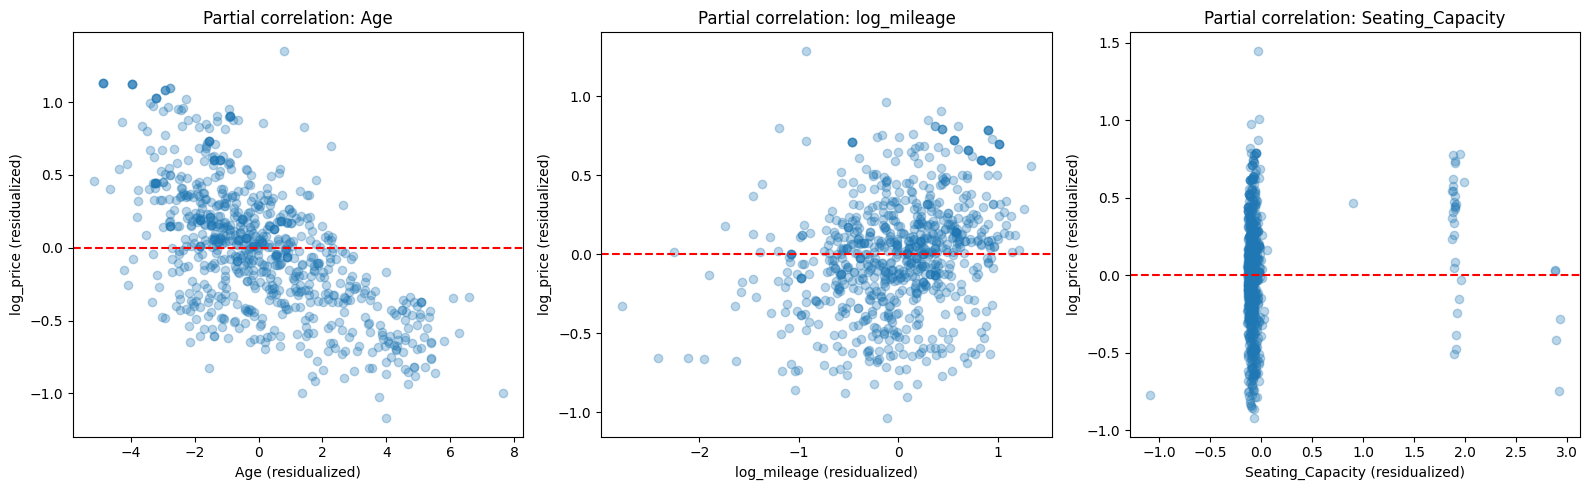

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(num_cols):
    # Everything except this variable
    other_num = [c for c in num_cols if c != var]
    
    # Residualize y on other variables
    m_y = LinearRegression().fit(X_train[other_num], y_train)
    resid_y = y_train - m_y.predict(X_train[other_num])
    
    # Residualize x on other variables
    m_x = LinearRegression().fit(X_train[other_num], X_train[var])
    resid_x = X_train[var] - m_x.predict(X_train[other_num])
    
    axes[i].scatter(resid_x, resid_y, alpha=0.3)
    axes[i].axhline(0, color='r', linestyle='--')
    axes[i].set_xlabel(f'{var} (residualized)')
    axes[i].set_ylabel('log_price (residualized)')
    axes[i].set_title(f'Partial correlation: {var}')

plt.tight_layout()
plt.show()

There doesn't seem to be any significant non-linearities. Age has a clear negative linear relationship with log price --> older cars are cheaper, and it looks pretty linear so no transformation needed there. Log mileage is similar, negative and roughly linear, which confirms the log transform we already applied was the right call. Seating capacity is basically just discrete clusters (most cars have 5 seats) so there's not much of a continuous relationship to speak of, it might be better treated as a categorical or just dropped since it's not adding much. 

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?

In [19]:
# Interaction: Age x log_mileage (older cars with high mileage are worth less)
X_train_complex = X_train.copy()
X_test_complex  = X_test.copy()

X_train_complex['Age_x_logmileage'] = X_train['Age'] * X_train['log_mileage']
X_test_complex['Age_x_logmileage']  = X_test['Age']  * X_test['log_mileage']

# Polynomial terms for Age and log_mileage
X_train_complex['Age_sq']        = X_train['Age'] ** 2
X_test_complex['Age_sq']         = X_test['Age'] ** 2
X_train_complex['log_mileage_sq'] = X_train['log_mileage'] ** 2
X_test_complex['log_mileage_sq']  = X_test['log_mileage'] ** 2

m_complex = evaluate("Model 4: Complex",
    LinearRegression(), X_train_complex, X_test_complex, y_train, y_test)


Model 4: Complex
  Train R²: 0.8369 | Train RMSE: 0.1829
  Test  R²: 0.8156 | Test  RMSE: 0.1875


There is very little improvement with this more complex model. Test R^2 goes from 0.8139 to 0.8156 and RMSE drops from 0.1884 to 0.1875, which is essentially nothing. The interactions and polynomial terms aren't adding much signal beyond what the categorical dummies already captured. The simple combined model from part 4 is basically just as good, which suggests the categoricals (brand, body type, fuel type, etc.) are doing most of the heavy lifting and the numeric relationships are already well-specified enough without extra complexity.

7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?

Overall, the main takewaway is that brand and body type just trump everything else for car prices. Knowing it's a Jeep SUV tells you way more than knowing it has 60k miles on it. The numeric-only model was pretty bad at 0.40 R^2, not because age and mileage don't matter, but because they're not the whole story.

The complex model was also not as helpful. I added interactions and squared terms thinking that there would be a meaningful bump, but I got nothing. Test R^2 moved by about 0.002. Due to this, I realized that more complexity doesn't automatically mean better, and if your categorical variables already capture most of the variation, there's not much left for fancy interactions to explain.

The clearest overfitting example was back in Q3 with polynomial features. Train R^2 kept climbing while test R^2 bounced around and barely improved. Here we didn't really overfit, we just hit a ceiling where the model had learned pretty much everything it could from the available features. Getting from 0.81 to something meaningfully better would probably require better data (ex. accident history, service records, etc.) rather than more transformations of what we already have.

8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [20]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Scale features first - Lasso is sensitive to scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_complex)
X_test_scaled  = scaler.transform(X_test_complex)

# Try a few alpha values
for alpha in [0.001, 0.01, 0.1]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    tr_pred = lasso.predict(X_train_scaled)
    te_pred = lasso.predict(X_test_scaled)
    n_selected = np.sum(lasso.coef_ != 0)
    print(f"\nalpha={alpha} | Features kept: {n_selected}")
    print(f"  Train R²: {r2_score(y_train, tr_pred):.4f} | Train RMSE: {root_mean_squared_error(y_train, tr_pred):.4f}")
    print(f"  Test  R²: {r2_score(y_test, te_pred):.4f} | Test  RMSE: {root_mean_squared_error(y_test, te_pred):.4f}")

# Best alpha - show which features survived
best_lasso = Lasso(alpha=0.001).fit(X_train_scaled, y_train)
feature_names = X_train_complex.columns
selected = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lasso.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)
print("\nSelected features:")
print(selected)


alpha=0.001 | Features kept: 44
  Train R²: 0.8331 | Train RMSE: 0.1851
  Test  R²: 0.8105 | Test  RMSE: 0.1901

alpha=0.01 | Features kept: 26
  Train R²: 0.8168 | Train RMSE: 0.1939
  Test  R²: 0.7884 | Test  RMSE: 0.2009

alpha=0.1 | Features kept: 5
  Train R²: 0.6309 | Train RMSE: 0.2752
  Test  R²: 0.6029 | Test  RMSE: 0.2752

Selected features:
                     Feature  Coefficient
46                    Age_sq    -0.112686
45          Age_x_logmileage    -0.108393
32       Body_Type_hatchback    -0.101371
9             Make_MG Motors     0.086491
35             Body_Type_suv     0.082129
38          Fuel_Type_petrol    -0.072080
0           Seating_Capacity     0.065355
33             Body_Type_muv    -0.058079
41      Transmission_6-Speed     0.054828
13              Make_Renault    -0.045842
6               Make_Hyundai     0.035954
8                   Make_Kia     0.033950
16               Make_Toyota     0.033643
42      Transmission_7-Speed     0.033304
34           Bo

At alpha=0.001, Lasso keeps 44 of 49 features and performs basically identically to the full model (test R^2 0.81, RMSE 0.19). At alpha=0.01 it gets more aggressive, dropping to 26 features with a small performance hit. At alpha=0.1 it gets brutal, keeping only 5 features and R^2 tanks to 0.60.
The most important features by coefficient size are Age^2, the Age×log_mileage interaction, body type (hatchback hurts price, SUV helps), and MG Motors being a premium brand. Interestingly enough, color barely matters. Most color coefficients are tiny and get zeroed out at higher alphas. The features Lasso kills last are the ones we'd expect: age, body type, brand, and fuel type. Color and some of the smaller brands are basically noise.